# Plot morphological parameters
- This script is used to visualize the relationship between morphological parameters and temperature reductions.
- Simulations: CNTL, TranAlbe

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
import string

In [2]:
ds_HK_mask = xr.open_dataset('../../HK/mask/mask_HK_lat_lon.nc')
ds_HK_mask_urban = ds_HK_mask['PCT_URBAN']>0
ds_HK_mask_urban

<xarray.DataArray 'PCT_URBAN' (lat: 60, lon: 60)> Size: 4kB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(60, 60))
Coordinates:
  * lat      (lat) float64 480B 22.06 22.07 22.08 22.09 ... 22.67 22.68 22.69
  * lon      (lon) float64 480B 113.8 113.8 113.8 113.8 ... 114.4 114.5 114.5

In [3]:
ds_surf = xr.open_dataset('../../HK/surface_data/usurf/Usurf_surfdata_HK_1.2x1.2_SSP5-8.5_2035_78pfts_c250811.nc')
ds_surf_urban_morp = ds_surf[['HT_ROOF', 'CANYON_HWR', 'WTLUNIT_ROOF', 'WTROAD_PERV', 'PCT_URBAN', 'LANDFRAC_PFT']].sel(numurbl=2)
ds_surf_urban_morp = ds_surf_urban_morp.rename({'lsmlat': 'lat', 'lsmlon': 'lon'}).assign_coords(lat=ds_HK_mask_urban.lat, lon=ds_HK_mask_urban.lon)
ds_surf_urban_morp = ds_surf_urban_morp.where(ds_HK_mask_urban)
ds_surf_urban_morp['WTLUNIT_PERV'] = (1-ds_surf_urban_morp['WTLUNIT_ROOF']) * ds_surf_urban_morp['WTROAD_PERV']
ds_surf_urban_morp['CANYON_WIDTH'] = ds_surf_urban_morp['HT_ROOF'] / ds_surf_urban_morp['CANYON_HWR']
ds_surf_urban_morp

<xarray.Dataset> Size: 231kB
Dimensions:       (lat: 60, lon: 60)
Coordinates:
  * lat           (lat) float64 480B 22.06 22.07 22.08 ... 22.67 22.68 22.69
  * lon           (lon) float64 480B 113.8 113.8 113.8 ... 114.4 114.5 114.5
Data variables:
    HT_ROOF       (lat, lon) float64 29kB nan nan nan nan ... nan nan nan nan
    CANYON_HWR    (lat, lon) float64 29kB nan nan nan nan ... nan nan nan nan
    WTLUNIT_ROOF  (lat, lon) float64 29kB nan nan nan nan ... nan nan nan nan
    WTROAD_PERV   (lat, lon) float64 29kB nan nan nan nan ... nan nan nan nan
    PCT_URBAN     (lat, lon) float64 29kB nan nan nan nan ... nan nan nan nan
    LANDFRAC_PFT  (lat, lon) float64 29kB nan nan nan nan ... nan nan nan nan
    WTLUNIT_PERV  (lat, lon) float64 29kB nan nan nan nan ... nan nan nan nan
    CANYON_WIDTH  (lat, lon) float64 29kB nan nan nan nan ... nan nan nan nan
Attributes: (12/46)
    Conventions:                              NCAR-CESM
    History_Log:                              created on: 08-15-25 18:13:26
    Source:                                   Community Land Model: CLM5
    Version:                                  custom-build
    Dataset_Version:                          5.3
    Logname:                                  yuansun
    ...                                       ...
    lai_raw_data_file_name:                   mksrf_landuse_ctsm53_pftlai_CLI...
    soil_color_raw_data_file_name:            mksrf_landuse_ctsm53_soilcolor_...
    soil_texture_mapunit_raw_data_file_name:  mksrf_soil_mapunits_5x5min_WISE...
    soil_texture_lookup_raw_data_file_name:   mksrf_soil_lookup.10level.WISE....
    fmax_raw_data_file_name:                  mksrf_fmax_0.125x0.125_c200220.nc
    VOC_EF_raw_data_file_name:                mksrf_vocef_0.5x0.5_simyr2000.c...

In [4]:
year = 2038
ds_delta_jja_mean = xr.open_dataset(f'./data_for_figure/changes_{year}_JJA_day.nc')
ds_cntl_jja_mean = xr.open_dataset(f'./data_for_figure/cntl_{year}_JJA_day.nc')
normalized_TSA_delta = ds_delta_jja_mean['TSA_U'] / (ds_cntl_jja_mean['TSA_U'] * ds_surf_urban_morp['WTLUNIT_ROOF']) # normalized by tsa_u and roof fraction
normalized_TG_delta = ds_delta_jja_mean['TG_U'] / (ds_cntl_jja_mean['TG_U'] * ds_surf_urban_morp['WTLUNIT_ROOF']) 
normalized_TG_delta 

<xarray.DataArray (lat: 60, lon: 60)> Size: 29kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(60, 60))
Coordinates:
  * lon      (lon) float32 240B 113.8 113.8 113.8 113.8 ... 114.4 114.5 114.5
  * lat      (lat) float32 240B 22.06 22.07 22.08 22.09 ... 22.67 22.68 22.69

In [5]:
ncols=2
nrows=1
linewidth = 0.5
fontsize = 6
labelsize = 6
labelcolor = '#6b6b6b'
tick_length = 4
ticklabel_pad = 0.2
boundarywidth = 0.5
x_list = ['WTLUNIT_ROOF', 'HT_ROOF'] 
y_list = ['WTLUNIT_PERV', 'CANYON_HWR'] #'CANYON_WIDTH'
x_label_list = [r'Roof fraction (unitless, 0$-$1)', 'Building height (m)']
y_label_list = [r'Pervious road fraction (unitless, 0$-$1)', 'Canyon height-to-width ratio (unitless)'] #'Canyon floor width (m)'
title_list = ['Urban surface fractions', 'Urban canyon forms']
pad = 2

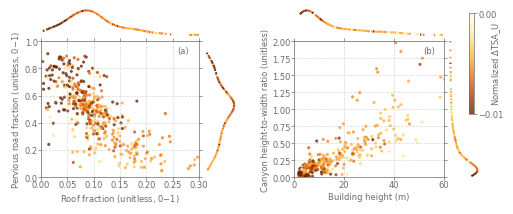

In [9]:
xmin_list = [0, 0]
xmax_list = [0.3, 60]
ymin_list = [0, 0] # 10
ymax_list = [1, 2] # 200
vmax = 0
vmin = -0.01
#cmap = cm.viridis
#cmap = cm.rainbow
#cmap='OrRd_r'
cmap='YlOrBr_r'
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(nrows, ncols, figsize=(5, 2))
ax = axes.flatten()

for i in range(ncols * nrows):
    divider = make_axes_locatable(ax[i])
    x = x_list[i]
    y = y_list[i]
    c = normalized_TSA_delta

    x, y, c = xr.align(ds_surf_urban_morp[x], ds_surf_urban_morp[y], c, join='inner')
    x1 = x.values.ravel()
    y1 = y.values.ravel()
    c1 = c.values.ravel()
    mask = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(c1)
    xv = x1[mask]
    yv = y1[mask]
    cv = c1[mask]

    # Scatter
    sc = ax[i].scatter(xv, yv, c=cv, s=5, alpha=0.8, vmax=vmax, vmin=vmin, cmap=cmap, edgecolors='none')
    # KDE for x
    kde_x = gaussian_kde(xv)
    x_grid = np.linspace(xv.min(), xv.max(), 300)
    kx = kde_x(x_grid)

    # KDE for y
    kde_y = gaussian_kde(yv)
    y_grid = np.linspace(yv.min(), yv.max(), 300)
    ky = kde_y(y_grid)

    # Top axis
    ax_top = divider.append_axes("top", size="20%", pad=0.05, sharex=ax[i])
    n_bins_x = 100
    bin_edges_x = np.linspace(xv.min(), xv.max(), n_bins_x + 1)
    bin_centers_x = 0.5 * (bin_edges_x[:-1] + bin_edges_x[1:])
    c_bin_mean_x = np.zeros(n_bins_x)
    for j in range(n_bins_x):
        mask_bin = (xv >= bin_edges_x[j]) & (xv < bin_edges_x[j + 1])
        c_bin_mean_x[j] = np.nanmean(cv[mask_bin]) if np.any(mask_bin) else np.nan
    kx_interp = kde_x(bin_centers_x)
    points = np.array([bin_centers_x, kx_interp]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, array=c_bin_mean_x, cmap=cmap, norm=norm, linewidth=1.5)
    ax_top.add_collection(lc)
    ax_top.autoscale()
    ax_top.axis("off")

    # Right axis
    ax_right = divider.append_axes("right", size="20%", pad=0.05, sharey=ax[i])
    n_bins_y = 100
    bin_edges_y = np.linspace(yv.min(), yv.max(), n_bins_y + 1)
    bin_centers_y = 0.5 * (bin_edges_y[:-1] + bin_edges_y[1:])
    c_bin_mean_y = np.zeros(n_bins_y)
    for j in range(n_bins_y):
        mask_bin = (yv >= bin_edges_y[j]) & (yv < bin_edges_y[j + 1])
        c_bin_mean_y[j] = np.nanmean(cv[mask_bin]) if np.any(mask_bin) else np.nan
    ky_interp = kde_y(bin_centers_y)
    points_y = np.array([ky_interp, bin_centers_y]).T.reshape(-1, 1, 2)
    segments_y = np.concatenate([points_y[:-1], points_y[1:]], axis=1)
    lc_y = LineCollection(segments_y, array=c_bin_mean_y, cmap=cmap, norm=norm, linewidth=1.5)
    ax_right.add_collection(lc_y)
    ax_right.autoscale()
    ax_right.axis("off")

    ax[i].set_xlim(xmin_list[i], xmax_list[i])
    ax_top.set_xlim(xmin_list[i], xmax_list[i])
    ax[i].set_ylim(ymin_list[i], ymax_list[i])
    ax_right.set_ylim(ymin_list[i], ymax_list[i])
    #ax[i].set_xticks([xmin_list[i], xmax_list[i]])
    ax[i].set_xlabel(x_label_list[i], fontsize=fontsize, color=labelcolor, labelpad=pad)
    ax[i].set_ylabel(y_label_list[i], fontsize=fontsize, color=labelcolor, labelpad=pad)
    ax[i].tick_params(axis='y', labelleft=True, right=True, labelsize=labelsize, length=tick_length/2, 
                      pad=ticklabel_pad, width=boundarywidth, colors=labelcolor)
    ax[i].tick_params(axis='x', labelbottom=True, top=True, labelsize=labelsize, length=tick_length/2, 
                      pad=ticklabel_pad, width=boundarywidth, colors=labelcolor) 
    for sp in ax[i].spines.values():
        sp.set_linewidth(boundarywidth)
        sp.set_edgecolor(labelcolor)
    ax[i].grid(True, which='both', axis='both',linestyle='--',linewidth=linewidth, alpha=0.5)    
    ax[i].set_title(f'({string.ascii_lowercase[i]})', color=labelcolor, fontsize=fontsize, 
                    x=0.9, y=0.85) #pad=30
cbar_pad = -0.05
cbar_yloc = 0.94
cbar = plt.colorbar(sc, ax=ax[i], orientation='vertical',  extend='neither', shrink=0.6, fraction=0.1,
                    pad=cbar_pad, anchor=(0, cbar_yloc))
offset_text = cbar.ax.yaxis.get_offset_text()
offset_text.set(size=labelsize, color=labelcolor)
offset_text.set_position((5, 2))
cbar.ax.tick_params(length=2,labelsize=labelsize, pad=1, width=boundarywidth, colors=labelcolor)
cbar.set_ticks([vmin, vmax])
cbar.outline.set_linewidth(boundarywidth)
cbar.outline.set_edgecolor(labelcolor)
cbar.set_label(r'Normalized $\Delta$TSA_U', fontsize=fontsize, color=labelcolor, labelpad=-10)    
plt.subplots_adjust(left=0.075, right=0.97, bottom=0.125, top=0.965, wspace=0.3, hspace=0.25)     
fig.savefig('urban_morphology.png', dpi=300)
fig.savefig('urban_morphology.pdf', dpi=600)

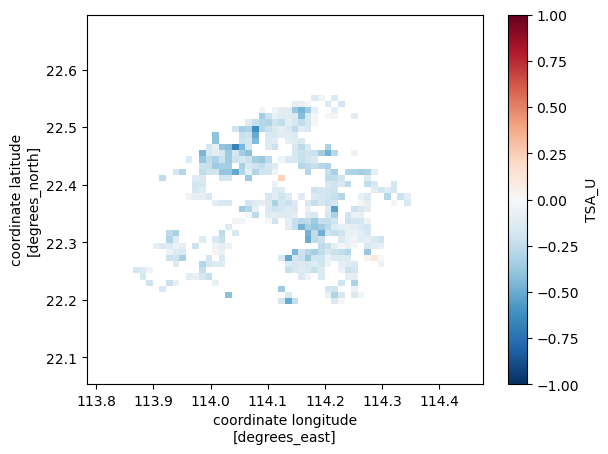

In [169]:
ds_delta_jja_mean['TSA_U'].plot(vmin=-1)

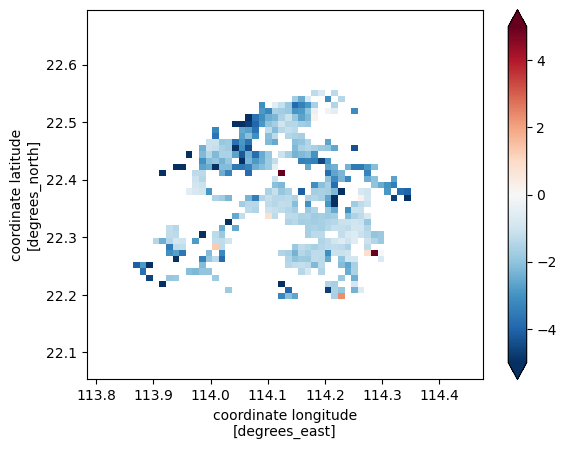

In [173]:
(ds_delta_jja_mean['TSA_U'] / ds_surf_urban_morp['WTLUNIT_ROOF']).plot(vmin=-5)